# 01 — Exploration et qualité des données

**Objectif :** comprendre les données Olist brutes avant toute modélisation, identifier les problèmes de qualité et justifier les décisions de nettoyage appliquées dans [`src/clean_data.py`](../src/clean_data.py).

**Données :** [Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) — ~100 000 commandes passées sur une marketplace brésilienne entre 2016 et 2018, réparties dans plusieurs tables relationnelles.

**Plan**
1. Vue d'ensemble des tables
2. Valeurs manquantes et doublons
3. Identifiants et clés
4. Couverture temporelle
5. Statuts de commande et périmètre d'analyse
6. Valeur des commandes et valeurs extrêmes
7. Comportement de réachat
8. Synthèse des décisions de nettoyage

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.append(str(Path.cwd().parent / "src"))
from clean_data import load_raw_tables
from config import FIGURES_DIR

BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#8a8983"
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e6e5e1",
    "axes.axisbelow": True,
    "axes.edgecolor": GREY,
    "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
})
pd.set_option("display.float_format", "{:,.2f}".format)

## 1. Vue d'ensemble des tables

Le fichier `olist_geolocation_dataset.csv` (1M de lignes, dont 26 % de doublons exacts) n'est pas chargé : l'analyse géographique se fait au niveau de l'État, déjà présent dans la table `customers`.

In [2]:
tables = load_raw_tables()

overview = pd.DataFrame({
    name: {
        "lignes": len(df),
        "colonnes": df.shape[1],
        "cellules manquantes (%)": 100 * df.isna().mean().mean(),
        "lignes dupliquées": df.duplicated().sum(),
    }
    for name, df in tables.items()
}).T.astype({"lignes": int, "colonnes": int, "lignes dupliquées": int})
overview

,lignes,colonnes,cellules manquantes (%),lignes dupliquées
customers,99441,5,0.00,0
orders,99441,8,0.62,0
order_items,112650,7,0.00,0
payments,103886,5,0.00,0
reviews,99224,7,21.01,0
products,32951,9,0.83,0
sellers,3095,4,0.00,0
category_translation,71,2,0.00,0


## 2. Valeurs manquantes et doublons

In [3]:
missing = pd.concat(
    {
        name: pd.DataFrame({"nb_manquants": df.isna().sum(), "pct_manquants": 100 * df.isna().mean()})
        for name, df in tables.items()
    },
    names=["table", "colonne"],
)
missing[missing["nb_manquants"] > 0]

nb_manquants  pct_manquants
table    colonne                                                   
orders   order_approved_at                       160           0.16
         order_delivered_carrier_date           1783           1.79
         order_delivered_customer_date          2965           2.98
reviews  review_comment_title                  87656          88.34
         review_comment_message                58247          58.70
products product_category_name                   610           1.85
         product_name_lenght                     610           1.85
         product_description_lenght              610           1.85
         product_photos_qty                      610           1.85
         product_weight_g                          2           0.01
         product_length_cm                         2           0.01
         product_height_cm                         2           0.01
         product_width_cm                          2           0.01

Les dates de livraison manquantes dans `orders` sont-elles des erreurs ou le reflet du cycle de vie de la commande ?

In [4]:
orders = tables["orders"]
pd.crosstab(
    orders["order_status"],
    orders["order_delivered_customer_date"].isna().map({True: "date manquante", False: "date renseignée"}),
)

order_delivered_customer_date,date manquante,date renseignée
order_status,,
approved,2,0
canceled,619,6
created,5,0
delivered,8,96470
invoiced,314,0
processing,301,0
shipped,1107,0
unavailable,609,0


**Interprétation**

- **`orders`** : les dates manquantes sont **structurelles** : une commande annulée, indisponible ou encore en transit n'a pas de date de livraison. Seules 8 commandes `delivered` n'ont pas de date de livraison, ce qui est négligeable et sans impact sur le RFM (qui utilise la date d'achat). Aucune imputation n'est donc pertinente.
- **`reviews`** : titre et commentaire sont optionnels pour le client. Les valeurs manquantes sont normales et la note (`review_score`) est complète.
- **`products`** : 610 produits (1,9 %) n'ont pas de catégorie. Les supprimer ferait disparaître leurs ventes du chiffre d'affaires, on les regroupe donc sous `unknown`. Les métadonnées descriptives (longueur du nom, nombre de photos, dimensions) ne sont pas utilisées dans l'analyse et restent `NULL` plutôt que d'être imputées arbitrairement.
- **Doublons** : aucune ligne dupliquée dans les tables utilisées.

## 3. Identifiants et clés

In [5]:
customers = tables["customers"]
reviews = tables["reviews"]

print(f"customer_id distincts        : {customers['customer_id'].nunique():,}")
print(f"customer_unique_id distincts : {customers['customer_unique_id'].nunique():,}")
print(f"review_id présents sur plusieurs commandes : {reviews['review_id'].duplicated().sum():,}")

customer_id distincts        : 99,441
customer_unique_id distincts : 96,096
review_id présents sur plusieurs commandes : 814


**Point critique pour le RFM :** Olist génère un nouveau `customer_id` **à chaque commande**. Le vrai identifiant client est `customer_unique_id`. Calculer la fréquence d'achat sur `customer_id` donnerait une fréquence de 1 pour tout le monde. Toutes les agrégations client utilisent donc `customer_unique_id`.

De même, `review_id` n'est pas une clé unique : la clé primaire de `reviews` est le couple `(review_id, order_id)`. Ces contraintes, ainsi que l'intégrité référentielle entre les tables, sont vérifiées automatiquement dans `clean_data.py` puis imposées par le schéma PostgreSQL.

## 4. Couverture temporelle

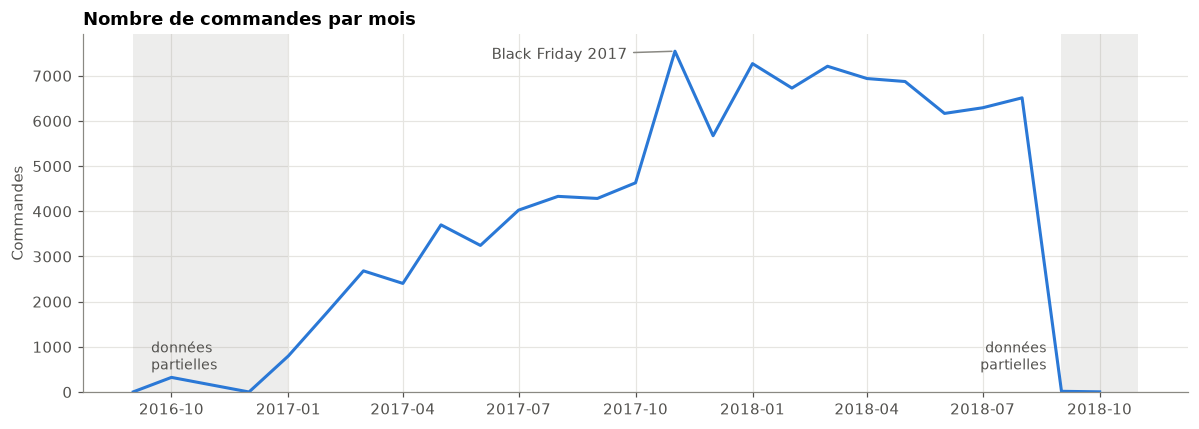

In [6]:
monthly_orders = orders["order_purchase_timestamp"].dt.to_period("M").value_counts().sort_index()
monthly_orders.index = monthly_orders.index.to_timestamp()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(monthly_orders.index, monthly_orders.values, color=BLUE, linewidth=2)
ax.axvspan(pd.Timestamp("2016-09-01"), pd.Timestamp("2017-01-01"), color=GREY, alpha=0.15, linewidth=0)
ax.axvspan(pd.Timestamp("2018-09-01"), pd.Timestamp("2018-10-31"), color=GREY, alpha=0.15, linewidth=0)
ax.annotate("Black Friday 2017", xy=(pd.Timestamp("2017-11-01"), monthly_orders.max()),
            xytext=(-120, -5), textcoords="offset points", color="#52514e",
            arrowprops={"arrowstyle": "-", "color": GREY})
ax.text(pd.Timestamp("2016-09-15"), 500, "données\npartielles", color="#52514e", fontsize=9)
ax.text(pd.Timestamp("2018-08-20"), 500, "données\npartielles", color="#52514e", fontsize=9, ha="right")
ax.set_title("Nombre de commandes par mois")
ax.set_ylabel("Commandes")
ax.set_ylim(0)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "monthly_orders.png", bbox_inches="tight")
plt.show()

**Interprétation**

- L'activité croît fortement en 2017 puis se stabilise autour de 6 500 à 7 000 commandes/mois en 2018, avec un pic au Black Friday (novembre 2017).
- **Biais à retenir :** fin 2016 et septembre/octobre 2018 sont quasi vides. L'extraction est incomplète, il ne s'agit pas d'une baisse d'activité. La dernière commande livrée date du **29/08/2018** : c'est la date de référence du calcul de la récence.
- **Censure à droite :** un client arrivé en juillet 2018 a eu beaucoup moins de temps pour racheter qu'un client de 2017. La fréquence d'achat des clients récents est mécaniquement sous-estimée (voir notebook 02).

## 5. Statuts de commande et périmètre d'analyse

In [7]:
(orders["order_status"].value_counts(normalize=True) * 100).round(2).rename("% des commandes").to_frame()

,% des commandes
order_status,
delivered,97.02
shipped,1.11
canceled,0.63
unavailable,0.61
invoiced,0.32
processing,0.30
created,0.01
approved,0.00


97 % des commandes sont livrées. **Le RFM est calculé sur les seules commandes `delivered`** : une commande annulée ou indisponible n'est pas un achat réalisé. Les commandes encore en cours (`shipped`, `invoiced`, …) représentent moins de 2 % du total et sont exclues par cohérence.

## 6. Valeur des commandes et valeurs extrêmes

In [8]:
payments = tables["payments"]
delivered_ids = orders.loc[orders["order_status"] == "delivered", "order_id"]
order_value = payments.groupby("order_id")["payment_value"].sum().loc[lambda s: s.index.isin(delivered_ids)]

q1, q3 = order_value.quantile([0.25, 0.75])
upper_fence = q3 + 1.5 * (q3 - q1)
print(order_value.describe(percentiles=[0.5, 0.9, 0.99]).round(2).to_string())
print(f"\nCommandes au-delà de Q3 + 1.5 IQR ({upper_fence:.0f} R$) : {(order_value > upper_fence).mean():.1%}")
print(f"Paiements à 0 R$ : {(payments['payment_value'] == 0).sum()} (vouchers / type non défini)")

count   96,477.00
mean       159.86
std        218.81
min          9.59
50%        105.28
90%        305.97
99%      1,052.39
max     13,664.08

Commandes au-delà de Q3 + 1.5 IQR (348 R$) : 7.9%
Paiements à 0 R$ : 9 (vouchers / type non défini)


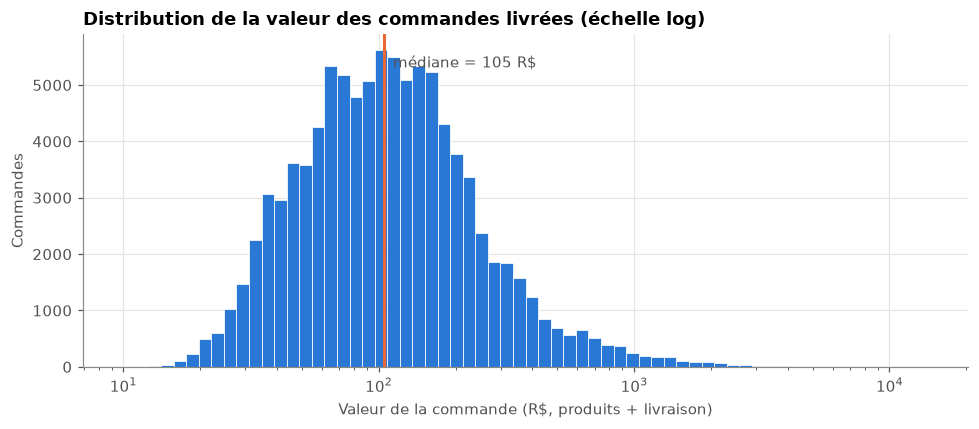

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
bins = pd.Series([10 * 1.12**i for i in range(65)])
ax.hist(order_value, bins=bins, color=BLUE, edgecolor="white", linewidth=0.5)
ax.set_xscale("log")
ax.axvline(order_value.median(), color=ORANGE, linewidth=2)
ax.text(order_value.median() * 1.08, ax.get_ylim()[1] * 0.9, f"médiane = {order_value.median():.0f} R$", color="#52514e")
ax.set_title("Distribution de la valeur des commandes livrées (échelle log)")
ax.set_xlabel("Valeur de la commande (R$, produits + livraison)")
ax.set_ylabel("Commandes")
fig.tight_layout()
plt.show()

**Interprétation**

- La distribution est très asymétrique à droite : médiane d'environ 105 R$, moyenne tirée vers le haut par une longue traîne (maximum > 13 000 R$).
- Environ 8 % des commandes dépassent la borne IQR, mais ce sont des **achats réels** (électroménager, informatique), pas des erreurs de saisie : elles sont **conservées**.
- Conséquence méthodologique : le score Monétaire est construit par **quantiles** (rangs), insensibles aux valeurs extrêmes, plutôt que par seuils sur la moyenne.
- Aucun prix négatif ou nul. Les 9 paiements à 0 R$ (bons d'achat) ne modifient pas les sommes et sont conservés.

## 7. Comportement de réachat

In [10]:
delivered_orders = orders[orders["order_status"] == "delivered"].merge(customers, on="customer_id")
orders_per_customer = delivered_orders.groupby("customer_unique_id")["order_id"].nunique()

(orders_per_customer.clip(upper=4).value_counts(normalize=True).sort_index() * 100).round(2) \
    .rename(index={4: "4+"}).rename("% des clients").rename_axis("commandes livrées").to_frame()

,% des clients
commandes livrées,
1,97.00
2,2.76
3,0.19
4+,0.05


**Interprétation :** **97 % des clients n'ont passé qu'une seule commande.** C'est la caractéristique majeure du jeu de données, et elle conditionne la méthode :
- des quintiles sur la Fréquence n'ont pas de sens (80 % des clients auraient la même valeur). Le score F utilise donc des seuils métier (1, 2, 3-4, 5+ commandes) ;
- la segmentation repose principalement sur **Récence × Montant**, les deux dimensions qui discriminent réellement les clients ;
- la fidélité est suivie séparément via un indicateur `is_repeat_customer`.

## 8. Synthèse des décisions de nettoyage

| Problème identifié | Décision | Justification |
|---|---|---|
| `customer_id` différent à chaque commande | Agréger sur `customer_unique_id` | Sinon, fréquence = 1 pour tous les clients |
| Codes postaux lus comme entiers (`01151` → `1151`) | Lecture en texte | Préserver les zéros initiaux d'un identifiant |
| 610 produits sans catégorie | Catégorie `unknown` | Conserver leurs ventes dans le chiffre d'affaires |
| Catégories en portugais | Ajout de `product_category_name_english` | Lisibilité (2 catégories absentes du fichier de traduction complétées) |
| Colonnes mal orthographiées (`*_lenght`) | Renommées `*_length` | Propreté du schéma |
| Métadonnées produit manquantes | Laissées à `NULL` | Non utilisées, une imputation serait arbitraire |
| Dates de livraison manquantes | Conservées | Structurelles (commande non livrée) |
| `review_id` non unique | Clé primaire `(review_id, order_id)` | Fidèle à la réalité des données |
| Commandes de forte valeur | Conservées | Achats réels, gérés par un scoring en quantiles |
| Table `geolocation` | Non utilisée | Analyse géographique au niveau de l'État |

Les contrôles d'intégrité (unicité des clés primaires, absence de clés étrangères orphelines, traduction complète des catégories) sont exécutés à chaque lancement de `clean_data.py`, qui s'arrête en cas d'anomalie.